In [7]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def load_expression(path):
    d = pd.read_csv(path, sep="\t", index_col=0)    
    d = d[d["GeneType"] == "protein_coding"]
    d = d[d["Canonical"]]
    d = d[d["Count"] >= 100]
    d = d[d["FPKM"] >= 10]
    print(d.shape)
    return d

dfs = []
names = []
for path in sorted(glob.glob("results/pseudobulk/*.tsv.gz")):
    name = path.split("/")[-1].replace(".tsv.gz", "")
    names.append(name)
    df = load_expression(path)
    dfs.append(df)  

(3587, 21)
(3638, 21)
(2872, 21)
(3613, 21)
(4007, 21)
(3656, 21)
(3558, 21)
(3712, 21)
(3318, 21)
(3889, 21)
(3740, 21)
(3615, 21)


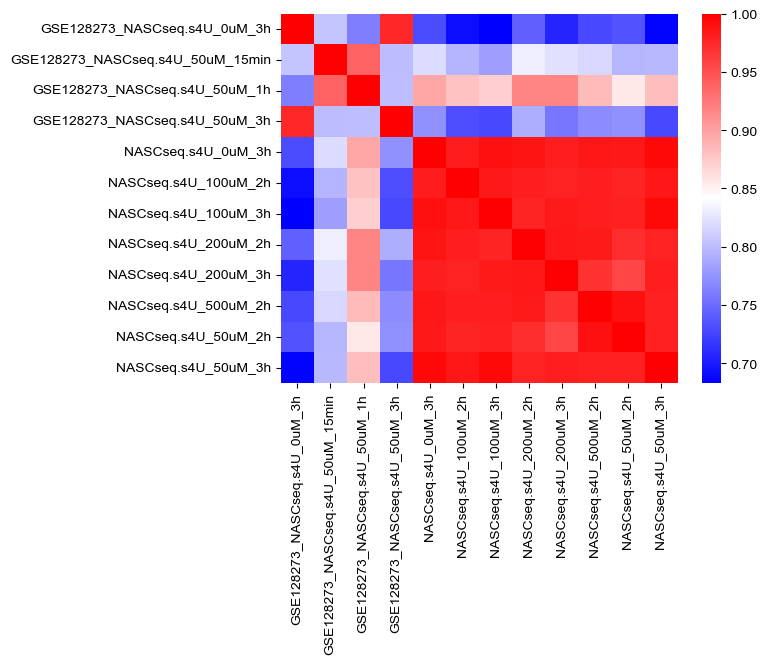

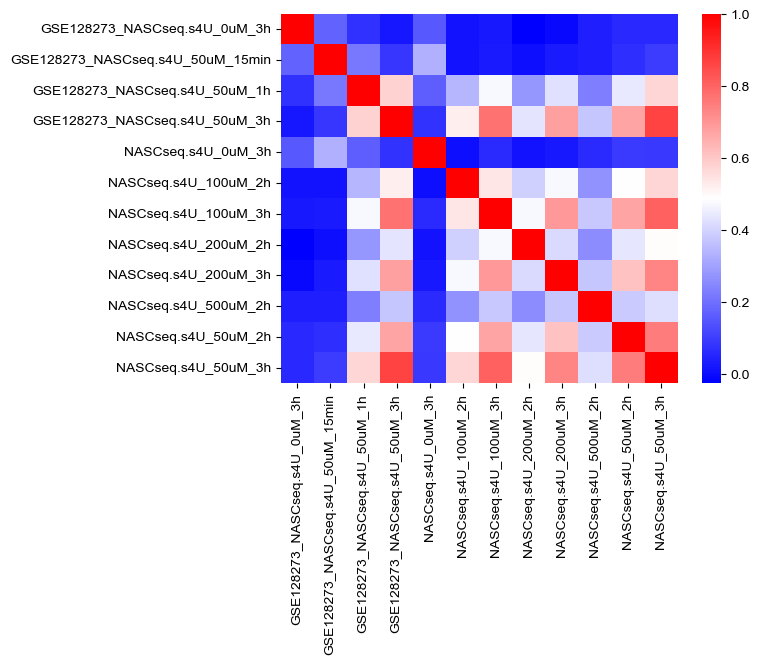

In [9]:
for col in ["FPKM", "NTR"]:
    array = []
    for name, df in zip(names, dfs):
        s = df[col]
        s.name = name
        array.append(s)
    m = pd.concat(array, axis=1, join="inner")
    sns.heatmap(m.corr(), cmap="bwr")
    plt.show()
    plt.close()